# Data Cleaning: Google Analytics Sales Data

This notebook prepares Google Ads performance data for analysis by cleaning and standardizing the raw dataset.

**Data Description**
a simulated Google Ads campaign promoting data analytics courses and services. 

Ad_ID : Unique ID of the ad campaign
Campaign_Name : Name of the campaign (with typos and variations)</br>
Clicks : Number of clicks received </br>
Impressions : Number of ad impressions</br>
Cost : Total cost of the ad (in ₹ or $ format with missing values)</br>
Leads : Number of leads generated</br>
Conversions : Number of actual conversions (signups, sales, etc.)</br>
Conversion Rate : Calculated conversion rate (Conversions ÷ Clicks)</br>
Sale_Amount : Revenue generated from the conversions</br>
Ad_Date : Date of the ad activity (in inconsistent formats like YYYY/MM/DD, DD-MM-YY)</br>
Location : City where the ad was served (includes spelling/case variations)</br>
Device : Device type (Mobile, Desktop, Tablet with mixed casing)</br>
Keyword : Keyword that triggered the ad (with typos)</br>

**What I did**
* Renamed columns using consistent lowercase and underscore formatting
* Cleaned string fields such as location, device, and keyword
* Standardized campaign_name values using fuzzy matching
* Split cost and sale_amount into separate currency and numeric amount columns
* Detected multiple ad_date formats and parsed them into a single datetime column
* Analyzed missing values and planned imputation for numerical columns using **KNN Imputer**
* Recalculated conversion rate and validated funnel relationships
* Dropped 3 rows that has Clicks, Conversion, and Conversion Rate missing
* Visualized original vs cleaned distributions of numerical columns to confirm effects of cleaning

**Result**</br>
df_clean contains normalized numeric fields, consistent values of Clicks, Conversion, and Conversion Rate that reflect real-world consistency


In [1]:
import pandas as pd

file_path = 'data/GoogleAds_DataAnalytics_Sales_Uncleaned.csv'
df = pd.read_csv(file_path)
print(df.head())

   Ad_ID          Campaign_Name  Clicks  Impressions     Cost  Leads  \
0  A1000    DataAnalyticsCourse   104.0       4498.0  $231.88   14.0   
1  A1001    DataAnalyticsCourse   173.0       5107.0  $216.84   10.0   
2  A1002    Data Anlytics Corse    90.0       4544.0  $203.66   26.0   
3  A1003  Data Analytcis Course   142.0       3185.0  $237.66   17.0   
4  A1004   Data Analytics Corse   156.0       3361.0   $195.9   30.0   

   Conversions  Conversion Rate Sale_Amount     Ad_Date   Location   Device  \
0          7.0            0.058       $1892  2024-11-16  hyderabad  desktop   
1          8.0            0.046       $1679  20-11-2024  hyderabad   mobile   
2          9.0              NaN       $1624  2024/11/16  hyderabad  Desktop   
3          6.0              NaN       $1225  2024-11-26  HYDERABAD   tablet   
4          8.0              NaN       $1091  2024-11-22  hyderabad  desktop   

                  Keyword  
0    learn data analytics  
1   data analytics course  
2   data

Here we can see inconsistent column names. Later in this notebook, I will standardise the names. NaN values are also present in the data. Let's check which columns have null values.

In [2]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns)

Index(['ad_id', 'campaign_name', 'clicks', 'impressions', 'cost', 'leads',
       'conversions', 'conversion_rate', 'sale_amount', 'ad_date', 'location',
       'device', 'keyword'],
      dtype='object')


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ad_id            2600 non-null   object 
 1   campaign_name    2600 non-null   object 
 2   clicks           2488 non-null   float64
 3   impressions      2546 non-null   float64
 4   cost             2503 non-null   object 
 5   leads            2552 non-null   float64
 6   conversions      2526 non-null   float64
 7   conversion_rate  1974 non-null   float64
 8   sale_amount      2461 non-null   object 
 9   ad_date          2600 non-null   object 
 10  location         2600 non-null   object 
 11  device           2600 non-null   object 
 12  keyword          2600 non-null   object 
dtypes: float64(5), object(8)
memory usage: 264.2+ KB
None


In [4]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [5]:
df.select_dtypes('object').describe()

,ad_id,campaign_name,cost,sale_amount,ad_date,location,device,keyword
count,2600,2600,2503,2461,2600,2600,2600,2600
unique,2600,4,2106,921,90,4,9,6
top,A1000,Data Analytcis Course,$246.3,$1719,2024-11-14,HYDERABAD,MOBILE,online data analytic
freq,1,680,4,9,47,661,311,453


In [6]:
# duplicate dataframe for cleaning
df_clean = df.copy()

In [7]:
for col in ['location', 'device', 'keyword']:
    df_clean[col] = df_clean[col].str.strip().str.lower()

In [8]:
df_clean.select_dtypes('object').describe()

,ad_id,campaign_name,cost,sale_amount,ad_date,location,device,keyword
count,2600,2600,2503,2461,2600,2600,2600,2600
unique,2600,4,2106,921,90,3,3,6
top,A1000,Data Analytcis Course,$246.3,$1719,2024-11-14,hyderabad,desktop,online data analytic
freq,1,680,4,9,47,1311,888,453


In [9]:
print(df_clean['campaign_name'].value_counts())

campaign_name
Data Analytcis Course    680
Data Analytics Corse     647
DataAnalyticsCourse      637
Data Anlytics Corse      636
Name: count, dtype: int64


In [10]:
df_clean.describe()

,clicks,impressions,leads,conversions,conversion_rate
count,2488.000000,2546.000000,2552.000000,2526.000000,1974.000000
mean,138.956994,4523.280833,20.003918,6.519002,0.048979
std,34.619376,869.927913,6.032317,2.272573,0.019987
min,80.000000,3000.000000,10.000000,3.000000,0.015000
25%,110.000000,3764.000000,15.000000,5.000000,0.035000
50%,139.000000,4518.500000,20.000000,7.000000,0.046000
75%,169.000000,5279.500000,25.000000,9.000000,0.058000
max,199.000000,5999.000000,30.000000,10.000000,0.123000


### Handling Typo Variants in Location and Campaign Name columns

In [11]:
for col in ['device', 'location', 'keyword']:
    print(f"\n{col} ({df_clean[col].nunique()} unique values):")
    print(df_clean[col].value_counts().to_string())
    print("-" * 40)


device (3 unique values):
device
desktop    888
mobile     878
tablet     834
----------------------------------------

location (3 unique values):
location
hyderabad    1311
hyderbad      656
hydrebad      633
----------------------------------------

keyword (6 unique values):
keyword
online data analytic      453
learn data analytics      444
data analytics course     440
analytics for data        429
data analitics online     420
data anaytics training    414
----------------------------------------


In [12]:
# %pip install thefuzz
from thefuzz import process

canonical_map = {
    'campaign_name': ['data analytics course'],
    'location':      ['hyderabad'],
}

def standardise_value(name, canonicals, threshold=70):
    match, score = process.extractOne(name, canonicals)
    return match if score >= threshold else name

for col, canonicals in canonical_map.items():
    df_clean[col] = df_clean[col].apply(
        lambda x, c=canonicals: standardise_value(x, c)
    )
    print(f"\n{col}:")
    print(df_clean[f'{col}'].value_counts())


campaign_name:
campaign_name
data analytics course    2600
Name: count, dtype: int64

location:
location
hyderabad    2600
Name: count, dtype: int64


In [13]:
print(df_clean.head())

   ad_id          campaign_name  clicks  impressions     cost  leads  \
0  A1000  data analytics course   104.0       4498.0  $231.88   14.0   
1  A1001  data analytics course   173.0       5107.0  $216.84   10.0   
2  A1002  data analytics course    90.0       4544.0  $203.66   26.0   
3  A1003  data analytics course   142.0       3185.0  $237.66   17.0   
4  A1004  data analytics course   156.0       3361.0   $195.9   30.0   

   conversions  conversion_rate sale_amount     ad_date   location   device  \
0          7.0            0.058       $1892  2024-11-16  hyderabad  desktop   
1          8.0            0.046       $1679  20-11-2024  hyderabad   mobile   
2          9.0              NaN       $1624  2024/11/16  hyderabad  desktop   
3          6.0              NaN       $1225  2024-11-26  hyderabad   tablet   
4          8.0              NaN       $1091  2024-11-22  hyderabad  desktop   

                  keyword  
0    learn data analytics  
1   data analytics course  
2   data

### Handling Composite Value in Cost and Sale Columns

In [14]:
# identifying variations in cost and sale_amount columns

for col in ['cost','sale_amount']:
    print(f'\n{col}:')
    print(df_clean[col].str[0].unique())

    df_clean[f'{col}_currency'] = df_clean[col].str[0].astype(str)
    df_clean[f'{col}_amount'] = pd.to_numeric(df_clean[col].str[1:], errors='coerce')
    print(df_clean[[col, f'{col}_currency', f'{col}_amount']].head())


cost:
['$' nan]
      cost cost_currency  cost_amount
0  $231.88             $       231.88
1  $216.84             $       216.84
2  $203.66             $       203.66
3  $237.66             $       237.66
4   $195.9             $       195.90

sale_amount:
['$' nan]
  sale_amount sale_amount_currency  sale_amount_amount
0       $1892                    $              1892.0
1       $1679                    $              1679.0
2       $1624                    $              1624.0
3       $1225                    $              1225.0
4       $1091                    $              1091.0


### Handling Mixed Data Format

In [15]:
import re

patterns = {
    'YYYY-MM-DD': re.compile(r'^\d{4}-\d{2}-\d{2}$'),
    'DD-MM-YYYY': re.compile(r'^\d{2}-\d{2}-\d{4}$'),
    'YYYY/MM/DD': re.compile(r'^\d{4}/\d{2}/\d{2}$'),
    'DD/MM/YYYY': re.compile(r'^\d{2}/\d{2}/\d{4}$'),
}

def detect_date_format(date_str):
    if pd.isna(date_str):
        return 'missing'
    date_str = str(date_str).strip()
    
    for fmt_name, pattern in patterns.items():
        if pattern.match(date_str):
            return fmt_name
    return 'unknown'

df_clean['date_format'] = df_clean['ad_date'].apply(detect_date_format)
print(df_clean['date_format'].value_counts())

date_format
YYYY-MM-DD    893
DD-MM-YYYY    863
YYYY/MM/DD    844
Name: count, dtype: int64


In [16]:
# see what slipped through
print(df_clean[df_clean['date_format'] == 'unknown']['ad_date'].unique())

# see one example of each format side by side
print(df_clean[['ad_date', 'date_format']].drop_duplicates('date_format'))

[]
      ad_date date_format
0  2024-11-16  YYYY-MM-DD
1  20-11-2024  DD-MM-YYYY
2  2024/11/16  YYYY/MM/DD


In [17]:
format_map = {
    'YYYY-MM-DD': '%Y-%m-%d',
    'DD-MM-YYYY': '%d-%m-%Y',
    'YYYY/MM/DD': '%Y/%m/%d',
    'DD/MM/YYYY': '%d/%m/%Y',
}


for fmt, group_idx in df_clean.groupby('date_format').groups.items():
    pd_fmt = format_map.get(fmt)
    if pd_fmt:
        df_clean.loc[group_idx, 'ad_date'] = pd.to_datetime(
            df_clean.loc[group_idx, 'ad_date'], format=pd_fmt, errors='coerce'
        )

df_clean['ad_date'] = pd.to_datetime(df_clean['ad_date'], errors='coerce')

print(df_clean['ad_date'].isna().sum())
print(df_clean[['ad_date', 'date_format']].drop_duplicates('date_format'))

0
     ad_date date_format
0 2024-11-16  YYYY-MM-DD
1 2024-11-20  DD-MM-YYYY
2 2024-11-16  YYYY/MM/DD


In [18]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ad_id                 2600 non-null   object        
 1   campaign_name         2600 non-null   object        
 2   clicks                2488 non-null   float64       
 3   impressions           2546 non-null   float64       
 4   cost                  2503 non-null   object        
 5   leads                 2552 non-null   float64       
 6   conversions           2526 non-null   float64       
 7   conversion_rate       1974 non-null   float64       
 8   sale_amount           2461 non-null   object        
 9   ad_date               2600 non-null   datetime64[ns]
 10  location              2600 non-null   object        
 11  device                2600 non-null   object        
 12  keyword               2600 non-null   object        
 13  cost_currency     

In [19]:
df_clean.select_dtypes('object').describe()

,ad_id,campaign_name,cost,sale_amount,location,device,keyword,cost_currency,sale_amount_currency,date_format
count,2600,2600,2503,2461,2600,2600,2600,2600,2600,2600
unique,2600,1,2106,921,1,3,6,2,2,3
top,A1000,data analytics course,$246.3,$1719,hyderabad,desktop,online data analytic,$,$,YYYY-MM-DD
freq,1,2600,4,9,2600,888,453,2503,2461,893


In [20]:
print(df_clean.head())

   ad_id          campaign_name  clicks  impressions     cost  leads  \
0  A1000  data analytics course   104.0       4498.0  $231.88   14.0   
1  A1001  data analytics course   173.0       5107.0  $216.84   10.0   
2  A1002  data analytics course    90.0       4544.0  $203.66   26.0   
3  A1003  data analytics course   142.0       3185.0  $237.66   17.0   
4  A1004  data analytics course   156.0       3361.0   $195.9   30.0   

   conversions  conversion_rate sale_amount    ad_date   location   device  \
0          7.0            0.058       $1892 2024-11-16  hyderabad  desktop   
1          8.0            0.046       $1679 2024-11-20  hyderabad   mobile   
2          9.0              NaN       $1624 2024-11-16  hyderabad  desktop   
3          6.0              NaN       $1225 2024-11-26  hyderabad   tablet   
4          8.0              NaN       $1091 2024-11-22  hyderabad  desktop   

                  keyword cost_currency  cost_amount sale_amount_currency  \
0    learn data analy

In [21]:
df_clean = df_clean.drop(columns=['cost', 'sale_amount','date_format'])
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ad_id                 2600 non-null   object        
 1   campaign_name         2600 non-null   object        
 2   clicks                2488 non-null   float64       
 3   impressions           2546 non-null   float64       
 4   leads                 2552 non-null   float64       
 5   conversions           2526 non-null   float64       
 6   conversion_rate       1974 non-null   float64       
 7   ad_date               2600 non-null   datetime64[ns]
 8   location              2600 non-null   object        
 9   device                2600 non-null   object        
 10  keyword               2600 non-null   object        
 11  cost_currency         2600 non-null   object        
 12  cost_amount           2503 non-null   float64       
 13  sale_amount_curren

## Handling null value

### Handling null value in numerical columns

In [22]:
df_clean.isnull().sum()

ad_id                     0
campaign_name             0
clicks                  112
impressions              54
leads                    48
conversions              74
conversion_rate         626
ad_date                   0
location                  0
device                    0
keyword                   0
cost_currency             0
cost_amount              97
sale_amount_currency      0
sale_amount_amount      139
dtype: int64

According to the funnel:
- impressions > clicks > leads > conversion
- conversion_rate column can be derived from conversions/click

In [23]:
cvr = df_clean[['clicks', 'conversions','conversion_rate']].copy()
cvr['clicks_calculated'] = (df_clean['conversions'] / df_clean['conversion_rate'])
cvr['cvr_calculated'] = (cvr['conversions'] / cvr['clicks']).round(3)
print(cvr.head(20))
print(f"Number of mismatches in conversion_rate: {(cvr['conversion_rate'] != cvr['cvr_calculated']).sum()}")

    clicks  conversions  conversion_rate  clicks_calculated  cvr_calculated
0    104.0          7.0            0.058         120.689655           0.067
1    173.0          8.0            0.046         173.913043           0.046
2     90.0          9.0              NaN                NaN           0.100
3    142.0          6.0              NaN                NaN           0.042
4    156.0          8.0              NaN                NaN           0.051
5    195.0          8.0              NaN                NaN           0.041
6    116.0          5.0            0.043         116.279070           0.043
7    184.0          3.0            0.016         187.500000           0.016
8    113.0          4.0            0.058          68.965517           0.035
9    166.0          9.0            0.054         166.666667           0.054
10   101.0          6.0            0.059         101.694915           0.059
11   101.0          5.0            0.050         100.000000           0.050
12   125.0  

From here, we can see that conversion rate is highly unreliable. This inform the imputing strategy for these three columns:

* If both Clicks and Conversions are available → recalculate CVR = conversions / clicks
* If one of Clicks or Conversions is missing but CVR is available → back-calculate the missing one
* If one of Clicks or Conversions is missing and CVR is unavailable → impute the missing one → recalculate CVR
* If both Clicks and Conversions are missing → drop the row

But before I perform the imputation, I would like to see how many rows in each group according to these criterions

In [24]:
c = df_clean['clicks'].notna()
cv = df_clean['conversions'].notna()
cvr = df_clean['conversion_rate'].notna()

conditions = {
    'both available → recalculate CVR':                c & cv,
    'one missing, CVR available → back-calculate':     (c ^ cv) & cvr,
    'one missing, CVR unavailable → impute':           (c ^ cv) & ~cvr,
    'both missing → drop':                             ~c & ~cv,
}

for label, mask in conditions.items():
    print(f"{mask.sum():>4}  {label}")

2417  both available → recalculate CVR
  30  one missing, CVR available → back-calculate
 150  one missing, CVR unavailable → impute
   3  both missing → drop


In [25]:
from sklearn.impute import KNNImputer

numeric_cols = ['clicks', 'impressions', 'leads', 'conversions', 'cost_amount', 'sale_amount_amount']

# step 1 — drop both missing
drop_mask = ~c & ~cv
df_clean = df_clean[~drop_mask].reset_index(drop=True)
print(f"Dropped {drop_mask.sum()} rows")

# step 2 — recompute flags after drop
c   = df_clean['clicks'].notna()
cv  = df_clean['conversions'].notna()
cvr = df_clean['conversion_rate'].notna()

# step 3 — back-calculate missing clicks or conversions
mask_clicks = ~c & cv & cvr
mask_conversions = c & ~cv & cvr

df_clean.loc[mask_clicks, 'clicks'] = (
    df_clean.loc[mask_clicks, 'conversions'] / df_clean.loc[mask_clicks, 'conversion_rate']
)
df_clean.loc[mask_clicks, 'strategy'] = 'back-calculated clicks'

df_clean.loc[mask_conversions, 'conversions'] = (
    df_clean.loc[mask_conversions, 'clicks'] * df_clean.loc[mask_conversions, 'conversion_rate']
)
df_clean.loc[mask_conversions, 'strategy'] = 'back-calculated conversions'

df_clean.loc[c & cv, 'strategy'] = 'recalculated CVR'

# step 4 — KNN impute remaining nulls across all numeric columns
imputer = KNNImputer(n_neighbors=5)
df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

# round whole number columns after imputation
df_clean[['clicks', 'impressions', 'leads', 'conversions']] = \
    df_clean[['clicks', 'impressions', 'leads', 'conversions']].round()

# step 5 — recalculate CVR on clean clicks and conversions
df_clean['cvr_clean'] = (df_clean['conversions'] / df_clean['clicks']).round(3)


df_clean['strategy'] = df_clean['strategy'].fillna('imputed clicks/conversions')

print(f"Remaining nulls:\n{df_clean[numeric_cols].isna().sum()}")
print(f"CVR nulls: {df_clean['cvr_clean'].isna().sum()}")

Dropped 3 rows
Remaining nulls:
clicks                0
impressions           0
leads                 0
conversions           0
cost_amount           0
sale_amount_amount    0
dtype: int64
CVR nulls: 0


In [26]:
df_clean = df_clean.drop(columns=['conversion_rate'])
df_clean = df_clean.rename(columns={'cvr_clean': 'conversion_rate'})

print("Remaining nulls in each column:")
print(df_clean.isnull().sum())

Remaining nulls in each column:
ad_id                   0
campaign_name           0
clicks                  0
impressions             0
leads                   0
conversions             0
ad_date                 0
location                0
device                  0
keyword                 0
cost_currency           0
cost_amount             0
sale_amount_currency    0
sale_amount_amount      0
strategy                0
conversion_rate         0
dtype: int64


In [27]:
# clicks should always be <= impressions
invalid = (df_clean['clicks'] > df_clean['impressions']).sum()
print(f"clicks > impressions: {invalid}")

# leads should always be <= clicks
invalid = (df_clean['leads'] > df_clean['clicks']).sum()
print(f"leads > clicks: {invalid}")

# conversions should always be <= leads
invalid = (df_clean['conversions'] > df_clean['leads']).sum()
print(f"conversions > leads: {invalid}")

# conversions should always be <= clicks
invalid = (df_clean['conversions'] > df_clean['clicks']).sum()
print(f"conversions > clicks: {invalid}")

clicks > impressions: 0
leads > clicks: 0
conversions > leads: 0
conversions > clicks: 0


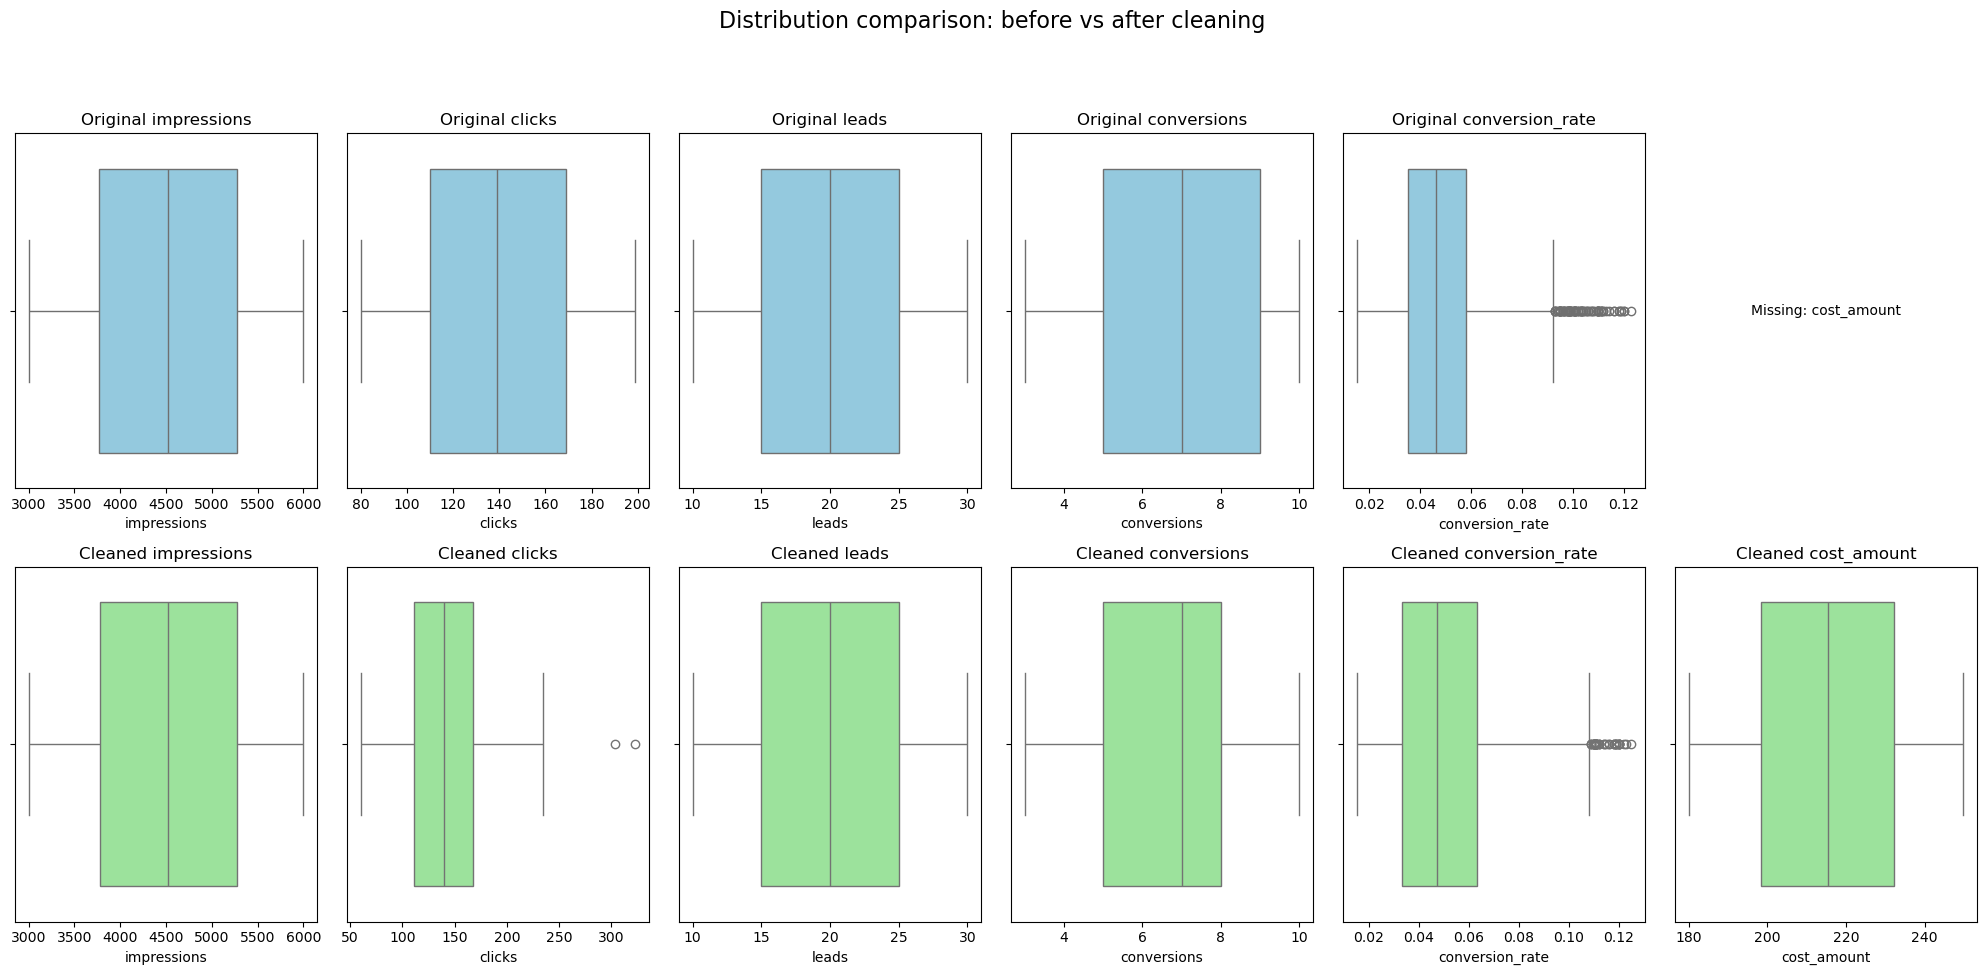

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['impressions', 'clicks', 'leads', 'conversions', 'conversion_rate', 'cost_amount']

fig, axes = plt.subplots(2, len(cols), figsize=(20, 10))

for i, col in enumerate(cols):
    if col in df.columns:
        sns.boxplot(x=df[col].dropna(), ax=axes[0, i], color='skyblue')
        axes[0, i].set_title(f'Original {col}')
        axes[0, i].set_xlabel(col)
    else:
        axes[0, i].text(0.5, 0.5, f'Missing: {col}', ha='center', va='center')
        axes[0, i].set_axis_off()

    if col in df_clean.columns:
        sns.boxplot(x=df_clean[col].dropna(), ax=axes[1, i], color='lightgreen')
        axes[1, i].set_title(f'Cleaned {col}')
        axes[1, i].set_xlabel(col)
    else:
        axes[1, i].text(0.5, 0.5, f'Missing: {col}', ha='center', va='center')
        axes[1, i].set_axis_off()

plt.suptitle('Distribution comparison: before vs after cleaning', y=1, size=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [29]:
print(df.describe())
print("-" * 40)
print(df_clean.describe())

            clicks  impressions        leads  conversions  conversion_rate
count  2488.000000  2546.000000  2552.000000  2526.000000      1974.000000
mean    138.956994  4523.280833    20.003918     6.519002         0.048979
std      34.619376   869.927913     6.032317     2.272573         0.019987
min      80.000000  3000.000000    10.000000     3.000000         0.015000
25%     110.000000  3764.000000    15.000000     5.000000         0.035000
50%     139.000000  4518.500000    20.000000     7.000000         0.046000
75%     169.000000  5279.500000    25.000000     9.000000         0.058000
max     199.000000  5999.000000    30.000000    10.000000         0.123000
----------------------------------------
            clicks  impressions        leads  conversions  \
count  2597.000000  2597.000000  2597.000000  2597.000000   
mean    139.299191  4522.583365    20.015402     6.525606   
min      60.000000  3000.000000    10.000000     3.000000   
25%     111.000000  3779.000000    15.00

In [30]:
print("click > original max:")
print(df_clean[df_clean['clicks'] > df['clicks'].max()][['clicks','strategy']])
print("-" * 40)
print("conversion_rate > 75th percentile:")
print(df_clean[df_clean['conversion_rate'] > df['conversion_rate'].quantile(0.75)]['strategy'].value_counts())

click > original max:
      clicks                strategy
141    323.0  back-calculated clicks
924    303.0  back-calculated clicks
1196   208.0  back-calculated clicks
1402   235.0  back-calculated clicks
----------------------------------------
conversion_rate > 75th percentile:
strategy
recalculated CVR               732
imputed clicks/conversions      41
back-calculated conversions      1
back-calculated clicks           1
Name: count, dtype: int64


Back-calculated clicks values exceed the observed range in the original data (max 199) in a small number of rows. These are retained as mathematically derived values from conversion_rate and conversions, not imputation artefacts. They represent ad placements with unusually low conversion rates requiring high click volumes to achieve.
conversions.

Same as the inflated whisk in conversion_rate, we can see that it was mostly from "Recalculated Clicks" from the original clicks and conversions value, which is mathematically correct. Thus, I decided to leave it be.

In [31]:
df_clean.head()

,ad_id,campaign_name,clicks,impressions,leads,conversions,ad_date,location,device,keyword,cost_currency,cost_amount,sale_amount_currency,sale_amount_amount,strategy,conversion_rate
0,A1000,data analytics course,104.0,4498.0,14.0,7.0,2024-11-16,hyderabad,desktop,learn data analytics,$,231.88,$,1892.0,recalculated CVR,0.067
1,A1001,data analytics course,173.0,5107.0,10.0,8.0,2024-11-20,hyderabad,mobile,data analytics course,$,216.84,$,1679.0,recalculated CVR,0.046
2,A1002,data analytics course,90.0,4544.0,26.0,9.0,2024-11-16,hyderabad,desktop,data analitics online,$,203.66,$,1624.0,recalculated CVR,0.100
3,A1003,data analytics course,142.0,3185.0,17.0,6.0,2024-11-26,hyderabad,tablet,data anaytics training,$,237.66,$,1225.0,recalculated CVR,0.042
4,A1004,data analytics course,156.0,3361.0,30.0,8.0,2024-11-22,hyderabad,desktop,online data analytic,$,195.90,$,1091.0,recalculated CVR,0.051


In [32]:
df_clean = df_clean.rename(columns={
    'sale_amount_amount':   'sale_amount',
    'sale_amount_currency': 'sale_currency',
})

df_clean = df_clean[['ad_id','campaign_name','ad_date','location','device','keyword',
                     'impressions','clicks','leads','conversions','conversion_rate',
                     'cost_currency','cost_amount','sale_currency','sale_amount', 'strategy']]
print(df_clean.head())

   ad_id          campaign_name    ad_date   location   device  \
0  A1000  data analytics course 2024-11-16  hyderabad  desktop   
1  A1001  data analytics course 2024-11-20  hyderabad   mobile   
2  A1002  data analytics course 2024-11-16  hyderabad  desktop   
3  A1003  data analytics course 2024-11-26  hyderabad   tablet   
4  A1004  data analytics course 2024-11-22  hyderabad  desktop   

                  keyword  impressions  clicks  leads  conversions  \
0    learn data analytics       4498.0   104.0   14.0          7.0   
1   data analytics course       5107.0   173.0   10.0          8.0   
2   data analitics online       4544.0    90.0   26.0          9.0   
3  data anaytics training       3185.0   142.0   17.0          6.0   
4    online data analytic       3361.0   156.0   30.0          8.0   

   conversion_rate cost_currency  cost_amount sale_currency  sale_amount  \
0            0.067             $       231.88             $       1892.0   
1            0.046            

In [33]:
df_clean.select_dtypes('object').describe()

,ad_id,campaign_name,location,device,keyword,cost_currency,sale_currency,strategy
count,2597,2597,2597,2597,2597,2597,2597,2597
unique,2597,1,1,3,6,2,2,4
top,A1000,data analytics course,hyderabad,desktop,online data analytic,$,$,recalculated CVR
freq,1,2597,2597,888,452,2500,2459,2417


### Inspect "NaN" value in cost_currency and sale_currency

In [34]:
print(df_clean['cost_currency'].value_counts())
print(df_clean['sale_currency'].value_counts())

cost_currency
$      2500
nan      97
Name: count, dtype: int64
sale_currency
$      2459
nan     138
Name: count, dtype: int64


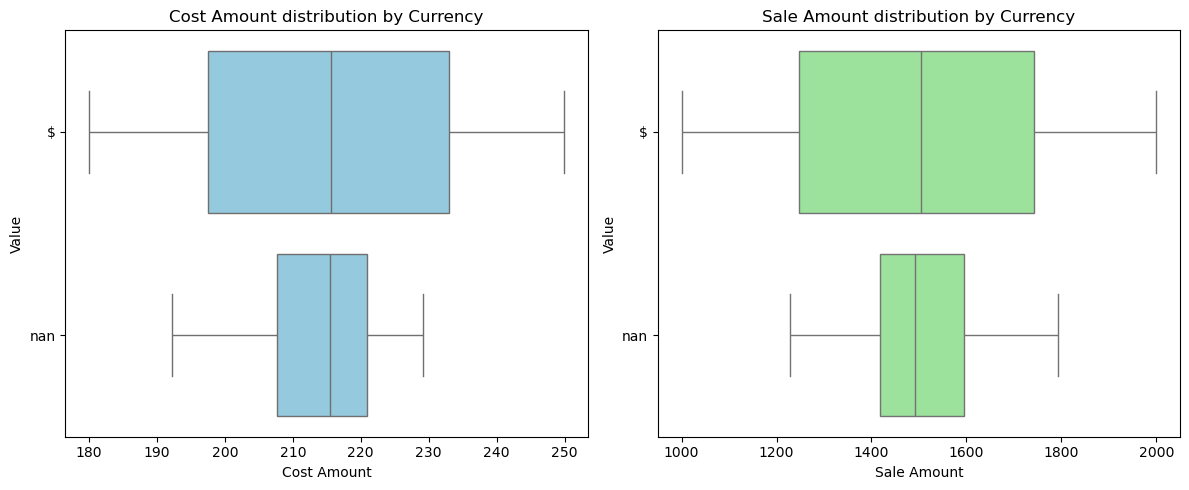

In [35]:
# check distribution of cost and sale_amount by currency to dedide if we can combine them or not
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='cost_amount', data=df_clean, y='cost_currency', ax=axes[0], color='skyblue')
axes[0].set_title('Cost Amount distribution by Currency')
axes[0].set_xlabel('Cost Amount')
axes[0].set_ylabel('Value')
sns.boxplot(x='sale_amount', data=df_clean, y='sale_currency', ax=axes[1], color='lightgreen')
axes[1].set_title('Sale Amount distribution by Currency')
axes[1].set_xlabel('Sale Amount')
axes[1].set_ylabel('Value')
plt.tight_layout()
plt.show()

The cost distribution for rows with missing currency labels is narrower than those with confirmed "\$" labels. This is expected because these rows had null cost values in the original data and were filled via KNN imputation, which naturally compresses variance by averaging neighbors. The distributions are otherwise centered around the same range, suggesting no second currency is present. This is further supported by the raw data inspection, which showed only "$" as the currency symbol across all non-null cost values.

Since the dataset contains only one currency ($) across both cost and sale amount, the currency columns carry no analytical value and are dropped. The strategy column, used to track imputation provenance during cleaning, is also dropped as it is not needed for analysis.

In [36]:
df_clean = df_clean.drop(columns=['cost_currency', 'sale_currency', 'strategy'])

### Final Data

The final data consisted of 12 columns (ad_id, campaign_name, ad_date, location, device, keyword, impressions, clicks, leads, conversions, conversion_rate, cost_amount, sale_amount) with no null values in each columns.

There are 2597 rows in the data.

In [37]:
print(df_clean.head())

   ad_id          campaign_name    ad_date   location   device  \
0  A1000  data analytics course 2024-11-16  hyderabad  desktop   
1  A1001  data analytics course 2024-11-20  hyderabad   mobile   
2  A1002  data analytics course 2024-11-16  hyderabad  desktop   
3  A1003  data analytics course 2024-11-26  hyderabad   tablet   
4  A1004  data analytics course 2024-11-22  hyderabad  desktop   

                  keyword  impressions  clicks  leads  conversions  \
0    learn data analytics       4498.0   104.0   14.0          7.0   
1   data analytics course       5107.0   173.0   10.0          8.0   
2   data analitics online       4544.0    90.0   26.0          9.0   
3  data anaytics training       3185.0   142.0   17.0          6.0   
4    online data analytic       3361.0   156.0   30.0          8.0   

   conversion_rate  cost_amount  sale_amount  
0            0.067       231.88       1892.0  
1            0.046       216.84       1679.0  
2            0.100       203.66       162

In [38]:
df_clean.to_csv('data/cleaned_data.csv', index=False)